# Colour Theory in Data Visualization
### Unit 1: Foundations of Visualization, Data Interpretation (UE24CS342AA9)
#### PPT6 Demo — Colour Fundamentals, Qualitative/Sequential/Diverging Scales, Accent Colour, Avoiding the Rainbow Scale

**Dataset:** World Happiness Report 2015 (`whr2015.csv`) — 158 countries with Region,
Happiness Score, and factor scores (Economy, Family, Health, Freedom, Trust, Generosity).

**The scenario:** You are a junior data analyst at **GlobalIndex Insights**, preparing a
briefing on well-being trends for a policy think-tank. Color is the most powerful (and
most easily misused) aesthetic channel in your toolkit — this notebook works through
every color-mapping principle from the lecture using the happiness data.

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("2015.csv")
print(f"Rows: {len(df)}  |  Columns: {list(df.columns)}")
df.head()

Rows: 158  |  Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']


,Country,Region,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


## 1. Color Fundamentals & Variable Mapping

Color is one of several **aesthetics** (alongside position, shape, size, line width,
line type) used to turn raw data into visual features. Some aesthetics can represent
**both** continuous and discrete data (position, size, color); others only work for
discrete data (shape, line type). Below, the same `Happiness Score` variable is mapped
to three different aesthetics side-by-side.

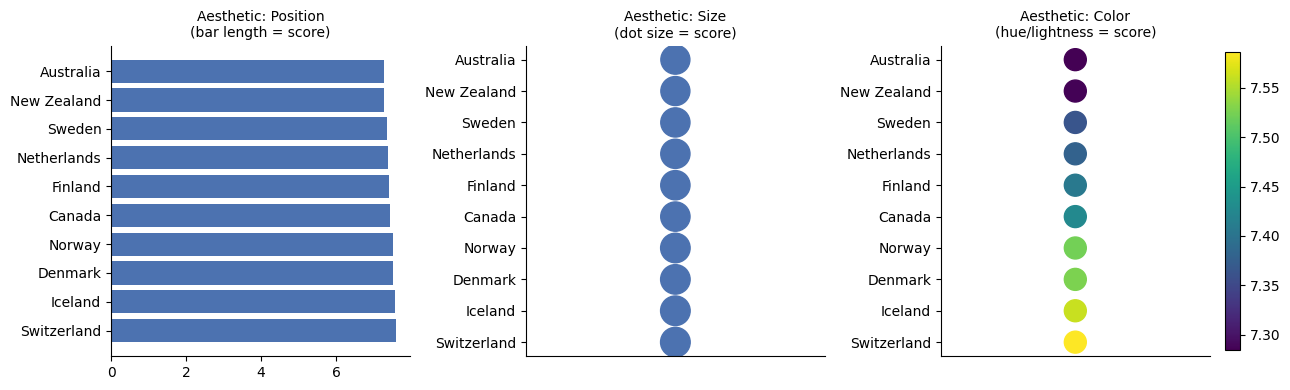

In [4]:
top10 = df.nsmallest(10, "Happiness Rank")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Aesthetic 1: position
axes[0].barh(top10["Country"], top10["Happiness Score"], color="#4C72B0")
axes[0].set_title("Aesthetic: Position\n(bar length = score)", fontsize=10)

# Aesthetic 2: size
axes[1].scatter([0.5]*len(top10), range(len(top10)),
                 s=top10["Happiness Score"] * 60, color="#4C72B0")
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10["Country"])
axes[1].set_xticks([])
axes[1].set_title("Aesthetic: Size\n(dot size = score)", fontsize=10)

# Aesthetic 3: color
sc = axes[2].scatter([0.5]*len(top10), range(len(top10)), s=250,
                      c=top10["Happiness Score"], cmap="viridis")
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(top10["Country"])
axes[2].set_xticks([])
axes[2].set_title("Aesthetic: Color\n(hue/lightness = score)", fontsize=10)
plt.colorbar(sc, ax=axes[2], fraction=0.05)

plt.tight_layout()
plt.show()

## 2. Principles of Color Mapping  

Color perception is **highly non-linear**, so scales must be designed around the human
visual system rather than raw math. **Categorical** mappings show group membership with
no implied order; **quantitative** mappings use a gradient for continuous magnitude.
Below, a matrix of average factor scores per region is encoded as a colored heatmap —
directly mirroring the lecture's "average monthly temperature by city" example.

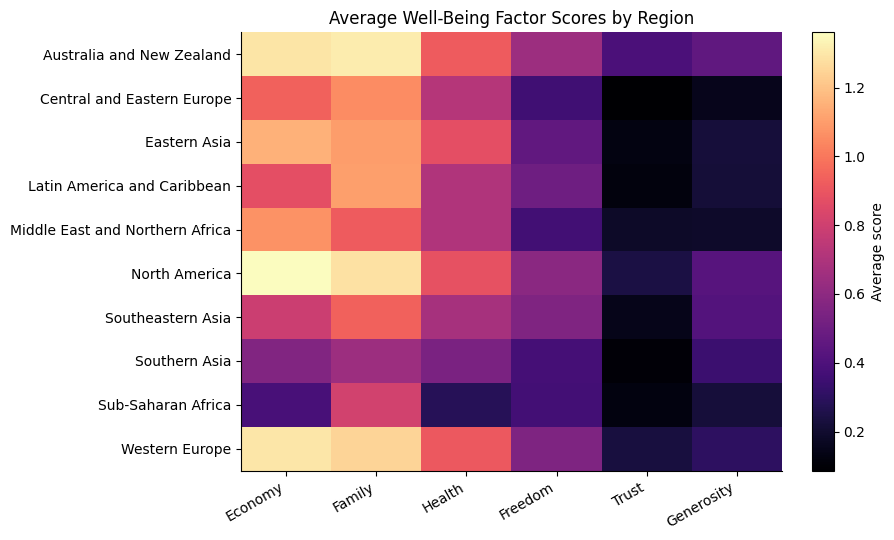

In [11]:
factor_cols = ["Economy (GDP per Capita)", "Family", "Health (Life Expectancy)",
               "Freedom", "Trust (Government Corruption)", "Generosity"]
region_matrix = df.groupby("Region")[factor_cols].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(region_matrix.values, cmap="magma", aspect="auto")
ax.set_xticks(range(len(factor_cols)))
ax.set_xticklabels([c.split(" (")[0] for c in factor_cols], rotation=30, ha="right")
ax.set_yticks(range(len(region_matrix)))
ax.set_yticklabels(region_matrix.index)
plt.colorbar(im, ax=ax, label="Average score", fraction=0.04)
ax.set_title("Average Well-Being Factor Scores by Region")
plt.tight_layout()
plt.show()

## 3. Three Functional Use Cases of Color  *(TB1, Ch4)*

| Use case | Scale type | Mapping |
|---|---|---|
| **To Distinguish** | Qualitative | Discrete, unordered items (regions, categories) |
| **To Represent Value** | Sequential / Diverging | Quantitative magnitudes (score, GDP, temperature) |
| **To Highlight** | Accent | Narrative focal points (the one point that matters) |

The next three sections work through each use case with the happiness dataset.

## 4. Color as a Tool to Distinguish: Qualitative Scales  

A qualitative scale must give every category **equivalent visual weight** — no hue
should look louder or imply an order. Below we recreate the lecture's own case study
("U.S. Population Growth Categorized by Region") using happiness data: countries sorted
by score, colored by `Region`.

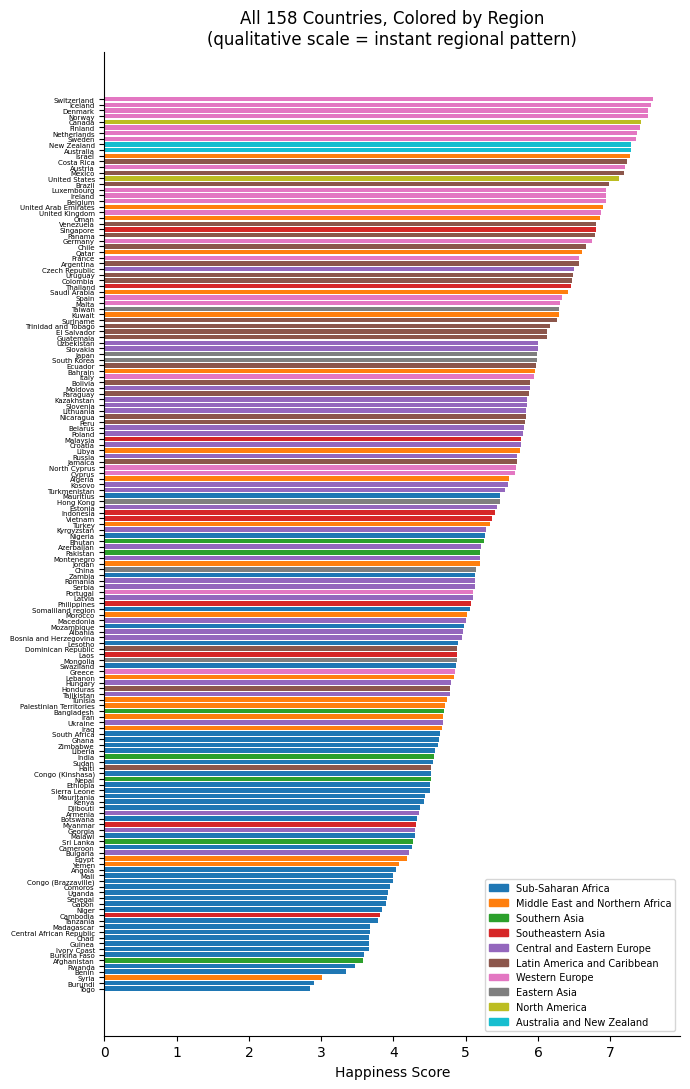

Regional clustering emerges instantly: Western Europe/North America dominate the top,
Sub-Saharan Africa dominates the bottom -- with no numeric labels required.


In [6]:
ordered = df.sort_values("Happiness Score", ascending=True)
regions = ordered["Region"].unique()
palette = plt.cm.tab10(np.linspace(0, 1, len(regions)))
color_map = dict(zip(regions, palette))
bar_colors = ordered["Region"].map(color_map)

fig, ax = plt.subplots(figsize=(7, 11))
ax.barh(ordered["Country"], ordered["Happiness Score"], color=bar_colors)
ax.tick_params(axis="y", labelsize=5)
ax.set_xlabel("Happiness Score")
ax.set_title("All 158 Countries, Colored by Region\n(qualitative scale = instant regional pattern)")

handles = [patches.Patch(color=color_map[r], label=r) for r in regions]
ax.legend(handles=handles, loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()

print("Regional clustering emerges instantly: Western Europe/North America dominate the top,")
print("Sub-Saharan Africa dominates the bottom -- with no numeric labels required.")

## 5. Standard Qualitative Color Scales

Not all "10 distinct colors" palettes are equally safe. **Okabe-Ito** is the academic
Color Universal Design (CUD) standard, built to remain distinguishable for colorblind
viewers; **ColorBrewer Dark2** and **tab10** (matplotlib/ggplot2-style) are common
alternatives with varying accessibility.

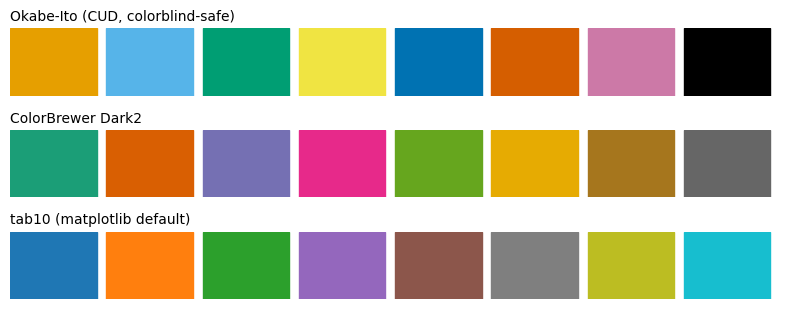

In [7]:
okabe_ito = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
             "#0072B2", "#D55E00", "#CC79A7", "#000000"]
dark2 = plt.cm.Dark2(np.linspace(0, 1, 8))
tab10 = plt.cm.tab10(np.linspace(0, 1, 8))

fig, axes = plt.subplots(3, 1, figsize=(8, 3.2))
for ax, colors, name in zip(axes, [okabe_ito, dark2, tab10],
                             ["Okabe-Ito (CUD, colorblind-safe)", "ColorBrewer Dark2", "tab10 (matplotlib default)"]):
    for i, c in enumerate(colors):
        ax.add_patch(patches.Rectangle((i, 0), 0.9, 1, color=c))
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(name, fontsize=10, loc="left")

plt.tight_layout()
plt.show()

## 6. Quantitative Scales: Sequential and Diverging

- **Sequential** scales map a continuous variable dark→light (or vice-versa) to show
  magnitude — good when there is no meaningful "zero" or midpoint.
- **Diverging** scales stitch two sequential scales together at a **neutral midpoint**,
  ideal when values naturally fall above/below something (zero, an average, a baseline).

Below: `Economy (GDP per Capita)` as a **sequential** scale, and `Trust (Government
Corruption)` expressed as **deviation from the global mean** on a **diverging** scale.

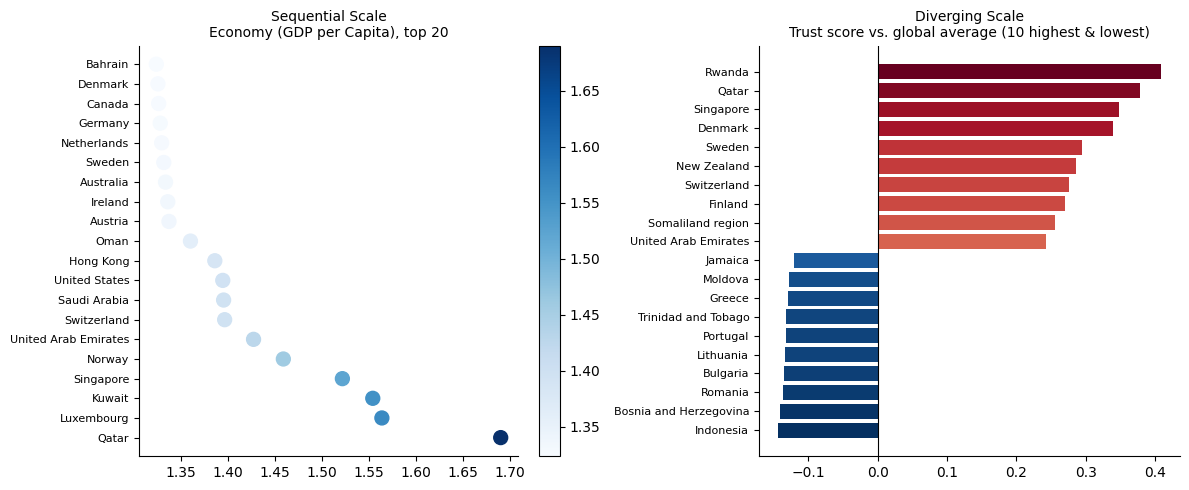

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sequential: no natural midpoint, just low -> high magnitude
top20 = df.nlargest(20, "Economy (GDP per Capita)")
sc1 = axes[0].scatter(top20["Economy (GDP per Capita)"], range(len(top20)),
                       c=top20["Economy (GDP per Capita)"], cmap="Blues", s=100)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20["Country"], fontsize=8)
axes[0].set_title("Sequential Scale\nEconomy (GDP per Capita), top 20", fontsize=10)
plt.colorbar(sc1, ax=axes[0], fraction=0.05)

# Diverging: deviation from the global mean trust score, centered at 0
trust_dev = df["Trust (Government Corruption)"] - df["Trust (Government Corruption)"].mean()
df_dev = df.assign(trust_dev=trust_dev)
sample = pd.concat([df_dev.nlargest(10, "trust_dev"), df_dev.nsmallest(10, "trust_dev")])
sample = sample.sort_values("trust_dev")
norm = TwoSlopeNorm(vmin=sample["trust_dev"].min(), vcenter=0, vmax=sample["trust_dev"].max())
sc2 = axes[1].barh(sample["Country"], sample["trust_dev"],
                    color=plt.cm.RdBu_r(norm(sample["trust_dev"])))
axes[1].axvline(0, color="black", lw=0.8)
axes[1].tick_params(axis="y", labelsize=8)
axes[1].set_title("Diverging Scale\nTrust score vs. global average (10 highest & lowest)", fontsize=10)

plt.tight_layout()
plt.show()

## 7. Color as a Tool to Highlight: Accent Scales  *(Sec 4.3)*

Accent scales pair a **drab, desaturated baseline** with a **vivid, saturated
highlight** to direct the eye to the one story that matters — exactly like the lecture's
Texas/Louisiana case study (two states in the same region with opposite growth
trajectories). Here, within **Latin America and Caribbean**, Trinidad & Tobago has the
lowest Trust score in the region while Uruguay has the highest — a hidden divide that a
single "regional average" color would completely erase.

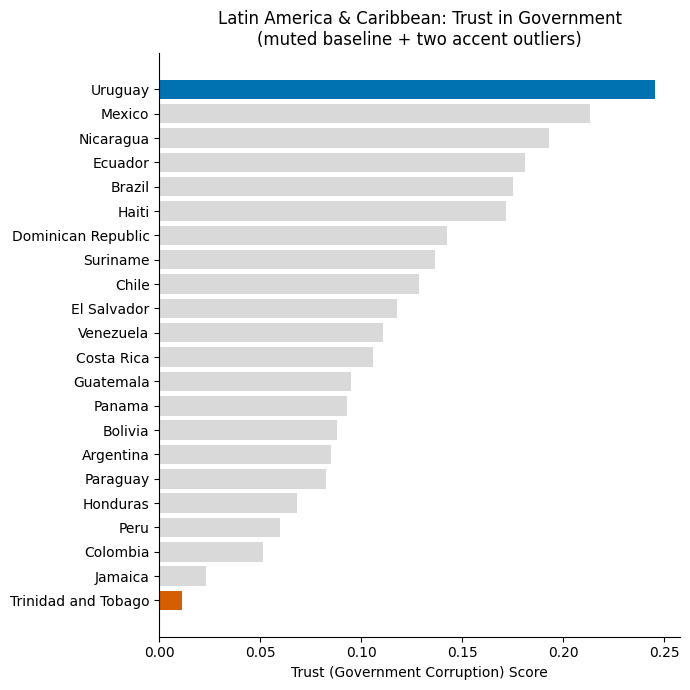

Both countries share a region, a qualitative color, and similar overall happiness ranks --
yet sit at opposite ends of institutional trust. The accent scale surfaces exactly that story.


In [9]:
region_df = df[df["Region"] == "Latin America and Caribbean"].sort_values("Trust (Government Corruption)")

colors = ["#d9d9d9"] * len(region_df)
colors[list(region_df["Country"]).index("Trinidad and Tobago")] = "#D55E00"   # vivid accent: lowest
colors[list(region_df["Country"]).index("Uruguay")] = "#0072B2"              # vivid accent: highest

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(region_df["Country"], region_df["Trust (Government Corruption)"], color=colors)
ax.set_xlabel("Trust (Government Corruption) Score")
ax.set_title("Latin America & Caribbean: Trust in Government\n(muted baseline + two accent outliers)")
plt.tight_layout()
plt.show()

print("Both countries share a region, a qualitative color, and similar overall happiness ranks --")
print("yet sit at opposite ends of institutional trust. The accent scale surfaces exactly that story.")

## 8. Avoiding the "Rainbow Scale" Pitfall

The rainbow colormap is visually striking but **perceptually broken** for quantitative
data: it is **non-monotonic in lightness** (yellow/cyan are much lighter than red/blue at
the ends) and its two ends (dark red, dark violet) look nearly identical. Converting
both colormaps to grayscale exposes the problem instantly.

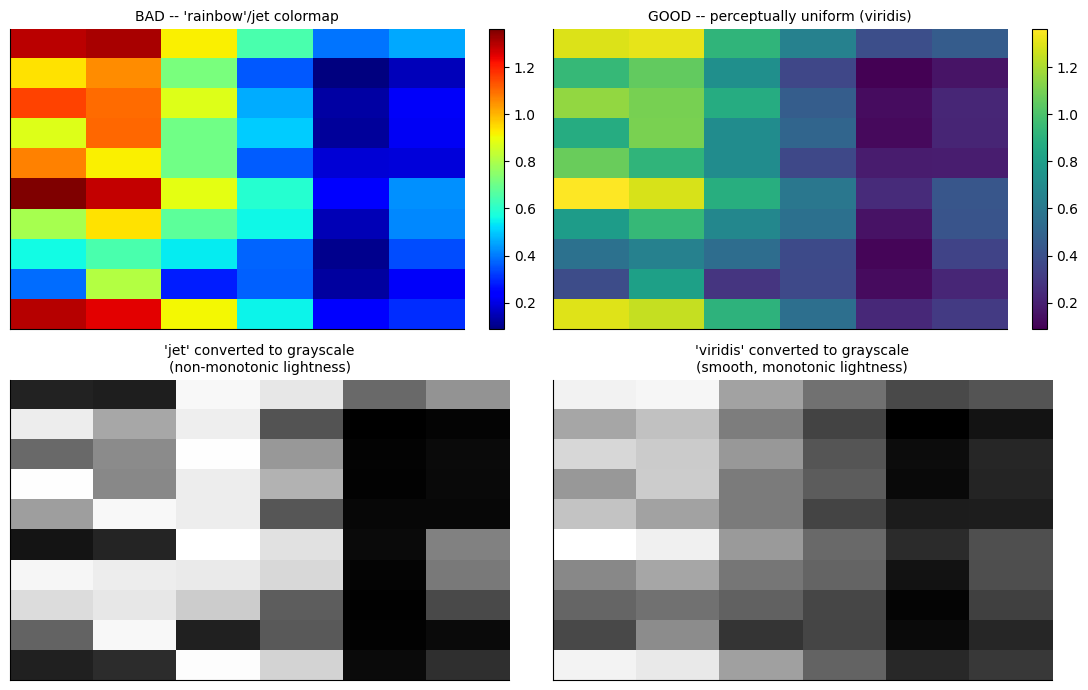

In [10]:
matrix = region_matrix.values  # reuse the region x factor matrix from Section 2

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

im1 = axes[0, 0].imshow(matrix, cmap="jet", aspect="auto")
axes[0, 0].set_title("BAD -- 'rainbow'/jet colormap", fontsize=10)
plt.colorbar(im1, ax=axes[0, 0], fraction=0.04)

im2 = axes[0, 1].imshow(matrix, cmap="viridis", aspect="auto")
axes[0, 1].set_title("GOOD -- perceptually uniform (viridis)", fontsize=10)
plt.colorbar(im2, ax=axes[0, 1], fraction=0.04)

# Grayscale versions expose the lightness problem directly
axes[1, 0].imshow(matrix, cmap="jet", aspect="auto")
gray_jet = plt.cm.jet(plt.Normalize()(matrix))[..., :3] @ [0.2126, 0.7152, 0.0722]
axes[1, 0].imshow(gray_jet, cmap="gray", aspect="auto")
axes[1, 0].set_title("'jet' converted to grayscale\n(non-monotonic lightness)", fontsize=10)

gray_viridis = plt.cm.viridis(plt.Normalize()(matrix))[..., :3] @ [0.2126, 0.7152, 0.0722]
axes[1, 1].imshow(gray_viridis, cmap="gray", aspect="auto")
axes[1, 1].set_title("'viridis' converted to grayscale\n(smooth, monotonic lightness)", fontsize=10)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## Key Takeaways

1. **Color is one aesthetic among several** (position, size, shape, line style) — choose
   it deliberately, not by default.
2. **Qualitative scales** need equal visual weight and no implied order; use accessible
   presets like **Okabe-Ito**, not arbitrary hues.
3. **Sequential** scales suit plain magnitude; **diverging** scales suit values that
   naturally split around a meaningful midpoint (zero, an average, a baseline).
4. **Accent scales** — drab baseline + vivid highlight — turn a dense figure into a
   focused story.
5. **Avoid the rainbow/jet colormap** for quantitative data — it is non-monotonic in
   lightness and misleads the eye about where large changes actually occur.

> *A good color scale should teach the viewer, not test them.*